# <center> Projekat iz predmeta Obrada astronomskih posmatranja 2</center>
### <center>Analiza varijacija u trenucima pomračenja kod eklipsno dvojnih sistema i statistička analiza parametara potencijalnog trećeg tela u sistemu</center>
### <center>Letnji semestar 2026. godine</center>

Student: Vesna Milošević

Mentor: prof. dr Anđelka Kovačević

In [1]:
"""
Skripta za analizu O-C dijagrama i fitovanje parametara trećeg tela.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle
from sklearn.metrics import r2_score
from funkcije import (
    OC_trece_telo,
    izracunaj_bootstrap_greske,
    izracunaj_masu_treceg_tela,
    izracunaj_bootstrap_gresku_mase
)

Kod trojnih zvezdanih sistema, koji su eklipsni, orbitalni period nije konstantan pa se pomračenja ne dešavaju na isti način kao kod dvojnih sistema. U tim sistemima mi posmatramo pomračenja, odnosno krive sjaja, kao da se radi o dvojnom sistemu, međutim u sistemu postoji treća zvezda ili jako masivna planeta koja svojom gravitacijom utiče na sistem.

O-C (eng. Observed–minus–Calculated) dijagrami predstavljaju razliku između posmatranog $O$ i predviđenog trenutka minimuma $C$. Ta razlika je prikazana na ordinati O-C dijagrama, dok je na apscisi vreme ili epoha, odnosno broj ciklusa od trenutka minimuma koji je uzet kao početni. U slučaju kada je orbitalni period konstantan, minimumi sjaja će se uvek detektovati kada je to i predviđeno, samim tim će razlika ovih vrednosti na O-C dijagramu biti jednaka nuli. U suprotnom, na O-C dijagramu će se uočiti promena koja ukazuje na proces koji utiče na sam eklipsno dvojni sistem.

Kada je u pitanju trojni sistem, postojanje trećeg tela je opisano Efektom svetlosnog kašnjenja.

### Efekat svetlosnog kašnjenja

Kada je promena perioda uzrokovana postojanjem trećeg pratioca javlja se efekat svetlosnog kašnjenja (eng. light time effect) (Irwin, 1952). Ovaj efekat se manifestuje na O-C dijagramu sinusnim trendom. Kada se treće telo nalazi najdalje posmatraču, predviđeni centar mase dvojnog sistema je najbliži. U tom slučaju svetlost prelazi najkraći put zbog čega stiže najranije. Ovo se na O-C dijagramu manifestuje kao minimum. U suprotnom slučaju, kada je treće telo najbliže posmatraču, centar mase dvojnog sistema je najdalji i svetlost prelazi najduži put
i stiže najkasnije, što se prikazuje kao maksimum na O-C dijagramu. Samim tim,
na osnovu analize promene perioda na O-C dijagramu moguće je odrediti orbitalne parametre trećeg pratioca.

Podaci su preuzeti sa [AAVSO](https://www.aavso.org/bob-nelsons-o-c-files) baze podataka (American Association of Variable Star Observers). Odavde su preuzeti samo podaci za sisteme kod kojih potencijalno postoji treći pratilac. Postoji kolona u podacima koja ima vrednosti yes, no i maybe. Takođe, na toj bazi mogu da se vide i izgledi OC dijagrama, tako da je odrađena i vizuelna inspekcija, ako postoji sinusni trend onda postoji i mogućnost da nastaje zbog postojanja trećeg pratioca.

### Za jedan sistem

Izabrala sam STPer jer su podaci izgledali reprezentativno (prate sinusni trend)

In [2]:
IME = 'Podaci/STPer.csv'
data = pd.read_csv(IME, names=['a','b','c','d','e','f','g','h','k'],
                   delimiter = ',')

Period je preuzet sa [O-C gateway baze](https://var.astro.cz/en). Na ovoj bazi mogu da se nađu periodi i za ostale sisteme.

In [3]:
t = np.array(data['a'])
oc= np.array(data['b'])
P2 = 2.648354

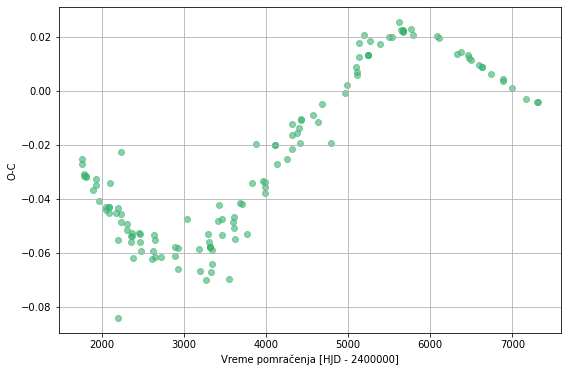

In [4]:
#Vidimo da li su dobro skinuti, u podacima već postoje izračunate OC vrednosti
plt.figure(figsize=(9, 6))
plt.scatter(t, oc, color='mediumseagreen', alpha=0.6)
plt.xlabel('Vreme pomračenja [HJD - 2400000]')
plt.ylabel('O-C')
plt.grid()
plt.show()

Kako bi se konstruisao O-C dijagram potrebno je znati trenutke u kojima su posmatrani minimumi, kao i trenutke koji odgovaraju teorijskom predviđanju ove pojave ako bi sistem bio dvojni:

$$ C(E) = t_0 + E · P_2,$$
gde je $t_0$ trenutak detekcije prvog minimuma, $P_2$ period dvojnog sistema i $E$ epoha. Epoha, odnosno broj perioda koji bi trebalo da je prošao od početnog do posmatranog trenutka je računata kao ceo deo od:

$$ E = [\frac{O-t_0}{P_2}].$$

Promena na O-C dijagramu usled efekta svetlosnog kašnjenja (Irwin 1952) je data kao:

$$ \Delta t = \frac{asini}{2.59 \cdot 10^{10}} \left\{ \frac{1-e^{2}}{1+ecos \nu} sin(\nu + \omega) + esin \omega \right\},$$

gde je $a$ velika poluosa orbite trećeg pratioca, $i$ inklinacija orbite trećeg pratioca u odnosu na ravan dvojnog sistema, $e$ ekscentricitet, $\nu$ prava anomalija i $\omega$ ugao između uzlaznog čvora i pravca ka perihelu.

Za konačno opisivanje OC dijagrama koristi se sledeća jednačina:

$$ MinI = C(E) + \Delta t + y,$$
gde je $MinI$ vreme minimuma a $y$ faktor za koji se promena pomera po y-osi kako bi oko nje bila simetrična. Ovom jednačinom se onda fituju podaci.

Kako bih zadala početne vrednosti parametara, treba da odredim period na neki način. Takođe mi je neophodan parametar $t_{03}$, odnosno početna pretpostavka vrednosti ovog parametra.

### Lomb-Scargle
Kako bih odredila period, koristim funkciju u pythonu [LombScargle](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lombscargle.html) iz Scipy biblioteke. Ova funkcija se koristi za računanje Lomb–Scargle periodograma, metode za analizu periodičnosti u podacima koji nisu ravnomerno uzorkovani u vremenu. Ova metoda je analogna Furijevoj transformaciji za slučajeve kada vremenski niz sadrži nepravilne vremenske razmake između merenja. Kako ovde merenja nisu vršena u jednalim razmacima, jer su vršena sa Zemlje od strane različitih posmatrača, izabrana je ova funkcija.

Funkcija na osnovu zadatih vremenskih trenutaka, vrednosti OC i opsega ugaonih frekvencija izračunava spektralnu snagu signala za svaku frekvenciju. Maksimumi periodograma ukazuju na moguće prisustvo periodičnih komponenti u podacima, odnosno na dominantne periode signala.

Pretpostavljeni period trojnog sistema je: 6176.666666666667 dana


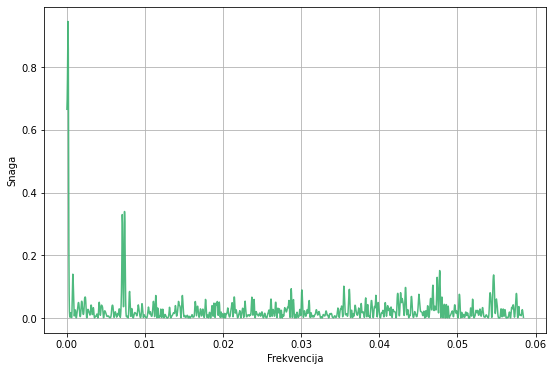

In [5]:
frequency, power = LombScargle(t, oc).autopower()
p=1/frequency[np.argmax(power)]  # Period trojnog sistema
p2=p + p*0.5 #Ovde pravim granice za opseg koje ću posle koristiti za fitovanje
p1=p - p*0.5

print('Pretpostavljeni period trojnog sistema je:',p, 'dana')

plt.figure(figsize=(9, 6))
plt.plot(frequency, power, label='default', color='mediumseagreen', alpha=0.9)
plt.xlabel('Frekvencija')
plt.ylabel('Snaga')
plt.grid()
plt.show()

Za prolazak kroz perihel, znamo da je tada treće telo najbliže centru mase, što bi značilo da je uticaj najveći i da će uticaj na kašnjenje biti najveći

In [6]:
#Traženje predpostavljene vrednosti za t0 - prolazak kroz perihel
Emax=t[np.argmax(oc)]
t01 = Emax - p/4
t02 = Emax + p/4
print('Pretpostavljeno vreme prolaska kroz perihel je:',Emax)

Pretpostavljeno vreme prolaska kroz perihel je: 5623


## Fitovanje 

Koristim funkciju [curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) iz Scipy bibilioteke, koju smo već koristili na vežbama.

In [7]:
#Ovo je uzeto jer sam videla u radu (Hajdu et. al 2019) da su dobili
#udaljenosti trećeg tela za sve sisteme u ovom opsegu
A1 = 149597900#km, = 1AU
A2 = 8975872000#km, = 30AU

granice = [[t01, p1, 0, A1, 0, -0.5], [t02, p2, 0.99, A2, 2*np.pi, 0.5]]

# Fitovanje
sad, pcov = curve_fit(OC_trece_telo, t, oc, bounds=granice, maxfev=5000)
t03, P3, e, asini, W, shift = sad

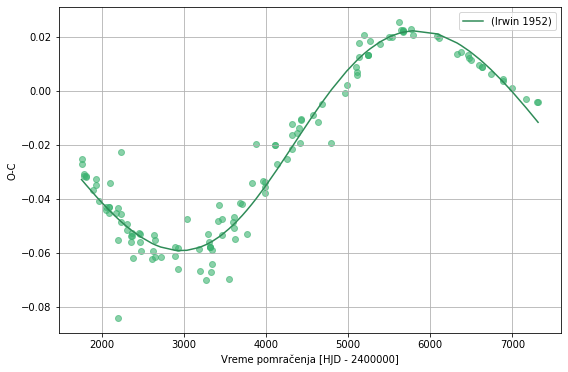

In [8]:
plt.figure(figsize=(9, 6))
plt.scatter(t, oc, color='mediumseagreen', alpha=0.6)
plt.plot(t, OC_trece_telo(t, *sad), color='seagreen', alpha=1, label='(Irwin 1952)')
plt.legend()
plt.grid()
plt.xlabel('Vreme pomračenja [HJD - 2400000]')
plt.ylabel('O-C')
plt.show()

## Procena neodređenosti parametara fita

Pri fitovanju nelinearnih modela, standardna metoda za procenu grešaka parametara (preko kovariacione matrice pcov u curve_fit-u) zasniva se na linearizaciji modela oko optimalne tačke. Ukoliko je model izrazito nelinearan ili su parametri korelisani, ova procena može biti nepouzdana i podceniti stvarnu grešku. Da bi se prevazišlo ovo ograničenje, koristi se **Bootstrap re-uzorkovanje** (eng. Bootstrap Resampling).

Princip rada metode:

1. **Empirijska raspodela**: Umesto da pretpostavljamo teorijsku raspodelu grešaka (npr. Gausovu), polazimo od pretpostavke da naš originalni uzorak od $n$ elemenata najbolje reprezentuje stvarnu populaciju iz koje su podaci potekli.
   
2. **Uzorkovanje sa ponavljanjem**: Iz originalnog skupa podataka nasumično biramo $n$ tačaka, ali tako da se svaka tačka nakon biranja "vraća" (sa ponavljanjem). To znači da će se u novom, "pseudo-uzorku", neke tačke pojaviti više puta, dok će neke biti izostavljene.

3. **Kreiranje raspodele parametara**: Ovaj proces ponavljamo $N$ puta (npr. $N = 500$ ili $1000$). Za svaki od $N$ generisanih pseudo-uzoraka ponovo pokrećemo nelinearni fit (curve_fit). Time umesto jedne vrednosti za svaki parametar dobijamo raspodelu od $N$ vrednosti.

4. **Određivanje neodređenosti**: Standardna devijacija dobijene raspodele za svaki parametar direktno predstavlja njegovu standardnu grešku. Ukoliko raspodela parametara odstupa od normalne (npr. zbog postavljenih granica/bounds), intervali poverenja se mogu preciznije odrediti preko percentila (npr. 2.5% i 97.5% percentili za 95% interval poverenja).


Glavna prednost bootstrapa je što je potpuno nezavisan od oblika funkcije i ne zahteva analitičko izvođenje, što ga čini izuzetno robusnim alatom.

In [9]:
#Granice parametara
greske, popt = izracunaj_bootstrap_greske(t, oc, granice, N=200)

In [10]:
print(f"{'t0'} = {sad[0]:.0f} ± {greske[0]:.0f}")
print(f"{'P3'} = {sad[1]:.0f} ± {greske[1]:.0f} {'[d]'}")
print(f"{'e'} = {sad[2]:.3f} ± {greske[2]:.3f}")
print(f"{'asini'} = {sad[3]*6.6845e-9:.2f} ± {greske[3]*6.6845e-9:.2f}{'[AU]'}")
print(f"{'w'} = {sad[4]:.2f} ± {greske[4]:.2f}")
print(f"{'y shift'} = {sad[5]:.5f} ± {greske[5]:.4f}")

t0 = 4079 ± 435
P3 = 6122 ± 134 [d]
e = 0.102 ± 0.061
asini = 7.08 ± 0.12[AU]
w = 2.81 ± 0.46
y shift = 0.01856 ± 0.0006


### Provera koliko je dobar fit

Izračunat je $R^2$, odnosno statistička mera poklapanja posmatranja sa teorijski opisanom promenom. Korišćena je funkcija [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html) iz biblioteke sklearn.metrics. Ovaj parametar se nalazi u opsegu od $- \infty$ do 1, gde 1 predstavlja 100% poklapanje.

##### Kako se računa $R^2$

Koeficijent determinacije definiše se izrazom:

$$R^2 = 1 - \frac{\sum_i (y_i-\hat{y}_i)^2}{\sum_i (y_i-\bar{y})^2}$$
gde su:

-  $y_i$ - eksperimentalne/merene vrednosti,    
- $\hat{y}_i$ - vrednosti dobijene modelom,    
- $\bar{y}$ - srednja vrednost eksperimentalnih podataka.

Veličina
$$\sum_i (y_i-\hat{y}_i)^2$$
predstavlja sumu kvadrata reziduala, odnosno ukupno odstupanje modela od podataka, dok izraz:

$$\sum_i (y_i-\bar{y})^2$$

predstavlja ukupnu sumu kvadrata, odnosno ukupno rasipanje podataka oko srednje vrednosti. Koeficijent $R^2$ meri koliki deo ukupne varijanse podataka model uspeva da objasni. Vrednost $R^2 = 1$ odgovara savršenom slaganju modela i podataka, $R^2 = 0$ znači da model nije bolji od aproksimacije srednjom vrednošću podataka, dok negativne vrednosti ukazuju na veoma loše slaganje modela sa podacima. 

In [11]:
r2z = r2_score(oc, OC_trece_telo(t, t03, P3, e, asini, W, shift))
print('R^2 =',r2z)

R^2 = 0.9495379736366725


### Mase

Moguće je odrediti funkciju mase trećeg tela na osnovu:

$$ f(m_3) = \frac{4 \pi ^2 (a \sin i)^3}{G P_3^2}.$$

Na osnovu poznate funkcije mase, moguće je odrediti i minimalnu masu trećeg tela $M_3$ ako su poznate mase ostale dve komponente u sistemu $M_1$ i $M_2$, ili bar njihov zbir:

$$ f(m_3) = \frac{(M_3 \sin i)^3}{(M_1 + M_2 + M_3)^2}.$$

Ova jednačina se rešava numerički. Kako je vrednost inklinacije nemoguće izračunati iz podataka o trenucima pomračenja, uzima se vrednost od 90° jer je najveća verovatnoća nalaženja takvog sistema da je eklipsni, to sam takođe videla jer je većina sistema iz rada sa velikim inklinacijama.

Kako bi se odredila minimalna masa koja odgovara trećem pratiocu $M_3$, neophodno je imati informaciju o ukupnoj masi dvojnog sistema. Taj podatak za većinu sistema nije poznat pa u prvoj aproksimaciji može da se pretpostavi da mase svih dvojnih sistema iznose dve Sunčeve mase (Hajdu et al. 2019).

In [12]:
M3 = izracunaj_masu_treceg_tela(P3, asini)
M3_error = izracunaj_bootstrap_gresku_mase(popt)
print(f"Masa trećeg tela iznosi: {M3:.2f} ± {M3_error:.2f} M_sun")

Masa trećeg tela iznosi: 3.28 ± 0.13 M_sun


<hr style="height:4px; border-width:0; background-color:mediumseagreen">

# <center> Za sve sisteme 

In [13]:
data = pd.read_csv('Rezultati.csv',
                   names=['a','b','c','d','e','f','g','h','i','j', 'k', 'l', 'm', 'n', 'o', 'p'],
                   delimiter=',', header=0)

t03= np.array(data['b'])
P3 = np.array(data['d'])
e =  np.array(data['f'])
asini = np.array(data['h'])
W = np.array(data['j'])
M3 = np.array(data['n'])
P2 = np.array(data['p'])

## Korelacioni plot $P_3$ od $P_2$

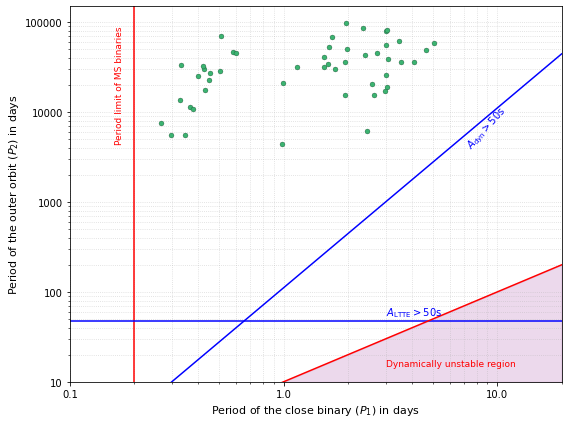

In [14]:
p1_linije = np.logspace(np.log10(0.1), np.log10(20), 500)

p2_dyn = 111.1 * (p1_linije ** 2)#Kosa plava linija
p2_unstable = 10.0 * p1_linije#Kosa crvena linija

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(P2, P3, c='mediumseagreen', s=25, edgecolors='black', linewidths=0.2, zorder=5)

ax.axvline(x=0.2, color='red', linestyle='-', linewidth=1.5)
ax.text(0.18, 20000, 'Period limit of MS binaries', color='red', rotation=90,
        verticalalignment='center', horizontalalignment='right', fontsize=9)

ax.axhline(y=47, color='blue', linestyle='-', linewidth=1.5)
ax.text(3, 55, r'$A_{\mathrm{LTTE}} > 50\mathrm{s}$', color='blue', fontsize=10)

ax.plot(p1_linije, p2_dyn, color='blue', linestyle='-', linewidth=1.5)
ax.text(7, 4000, r'$A_{\mathrm{dyn}} > 50\mathrm{s}$', color='blue', rotation=48, fontsize=10)


ax.plot(p1_linije, p2_unstable, color='red', linestyle='-', linewidth=1.5)

# Regioni
ax.fill_between(p1_linije, 10, p2_unstable, where=(p2_unstable > 10),
                color='purple', alpha=0.15)
ax.text(3, 15, 'Dynamically unstable region', color='red', fontsize=9)


# Podešavanje osa
ax.set_xscale('log')
ax.set_yscale('log')

#Odokativno
ax.set_xlim(0.1, 20)
ax.set_ylim(10, 150000)

# Oznake na osama
ax.set_xticks([0.1, 1, 10])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Oznake na y osi, jer inače bude bez 100000
ax.set_yticks([10, 100, 1000, 10000, 100000])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

# Nazivi osa
ax.set_xlabel(r'Period of the close binary ($P_1$) in days', fontsize=11)
ax.set_ylabel(r'Period of the outer orbit ($P_2$) in days', fontsize=11)

ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

### Poređenje sa literaturom

U radu (Hajdu et al. 2019) su dobili korelacioni plot:

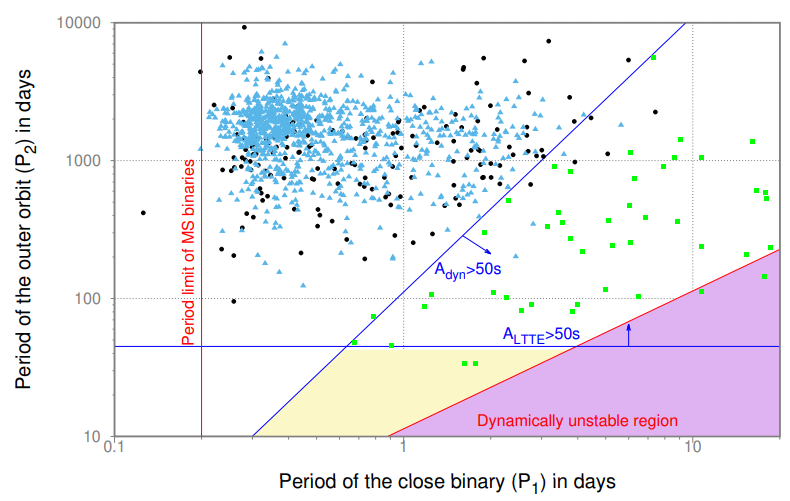

**Figure 9**. The location of the 992 triple star candidates (blue triangles) in the $P_1$ vs $P_2$ plane. For comparison we plotted those short-period Kepler, K2 and CoRoT-triple system candidates for which the inner and outer periods are $P_1$ ≤ 20 d and $P_2$ ≤ 10000 d. Following the work of Borkovits et al. (2016), the pure LTTE systems are marked with black circles, while triples with combine LTTE+dynamical ETV solution are plotted with green squares. The blue lines show the borders of the domains where the amplitudes of the LTTE and dynamical terms may exceed ∼ 50 sec, which can be regarded as a limit for an unambiguous detection. These limits were calculated for a hypothetical triple system of three, equally solar mass stars, with a typical outer eccentricity of $e_2$ = 0.35, and quite arbitrarily, $i_2$ = 60◦ and $ω_2$ = ±90◦. The shaded yellow area means that no LTTE can be detected, though dynamical effects may be significant and, therefore, certainly detectable. The purple region is a dynamically unstable region, in the sense of the stability criteria of Mardling & Aarseth (2001).

## Minimalna masa trećeg tela

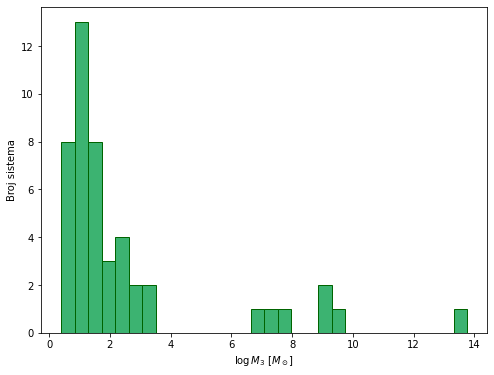

In [15]:
plt.figure(figsize=(8,6))
plt.hist(M3[M3<20], bins = 30, color= 'mediumseagreen', edgecolor='darkgreen', alpha=1)
plt.xlabel(r'$ \log M_3$ [$M_\odot$]')
plt.ylabel('Broj sistema')
plt.show()

### Poređenje sa rezultatima

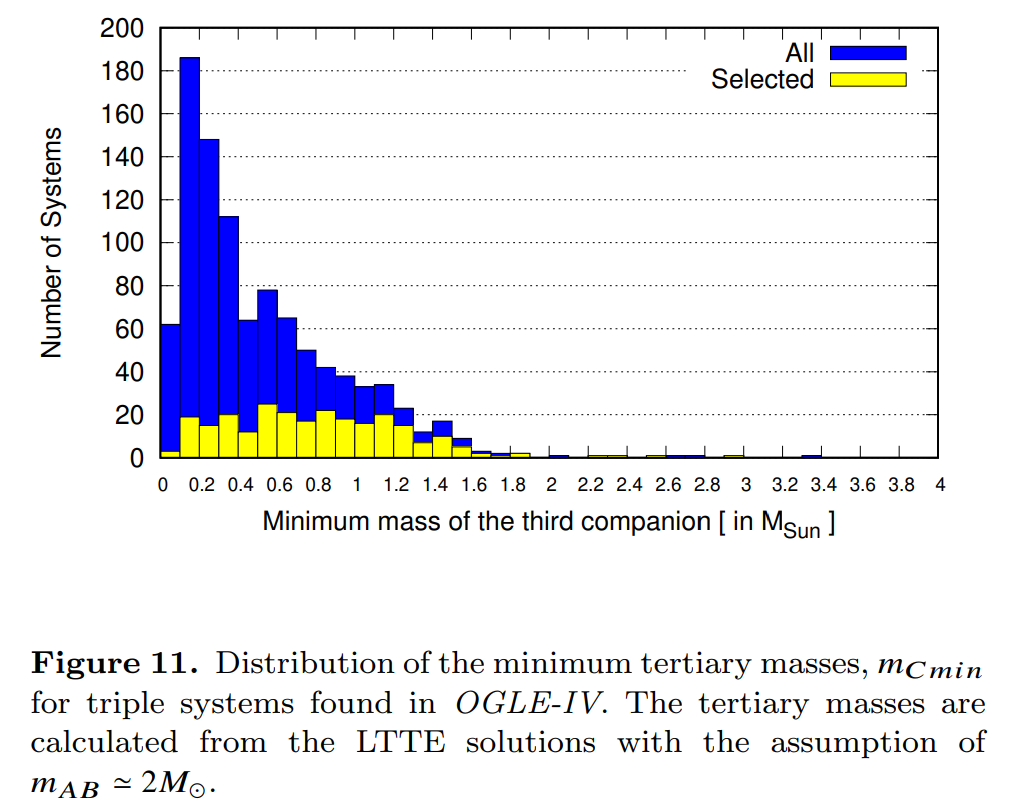

### Ideje za proširenje projekta

- Istražiti za koje sisteme postoje određene mase za pojedinačne komponente sistema, to bi poboljšalo rezultate za mase trećeg tela
- Izračunati amplitudu promene u OC dijagramu kod svih sistema, jer je i amplituda promene dobar pokazatelj da li se zapravo radi o trećem telu
- Videti na osnovu relacije masa-sjaj za zvezde na glavnom nizu i na osnovu udaljenosti do sistema, da li je moguće detektovati treće telo sa dobijenom masom
- Ispitivanje stabilnosti N-body simulacijama dinamičke evolucije trojnih sistema sa ovako dobijenim parametrima
- Ispitati i druge efekte koji mogu na sličan način da utiču na izgled OC dijagrama, kao na primer transfer mase

# Reference

- Hajdu T., Borkovits T., Forgács-Dajka E., Sztakovics J., Marschalkó G., Kutrovátz G. 2019. Eclipse timing variation analysis of OGLE-IV eclipsing binaries towards the Galactic Bulge - I. Hierarchical triple system candidates, vol. 485, 2562:2572.
- Irwin J. B. 1952. The Determination of a Light-Time Orbit. Astrophysical Journal, vol. 116, 211:217.
- Borkovits T., Hajdu T., Sztakovics J., Rappaport S., Levine A., Bıró I. B., Klagyivik P. 2016. A comprehensive study of the Kepler triples via eclipse timing, MNRAS, vol. 455, 4136:4165.
- Aarseth J., Mardling A. 2001. The Formation and Evolution of Multiple Star Systems, MNRAS, vol. 229, p. 77
- Baza podataka 1: https://www.aavso.org/bob-nelsons-o-c-files
- Baza podataka 2: https://var.astro.cz/en